<a href="https://colab.research.google.com/github/rangaraju1/Generative-AI-and-LLM-Applications/blob/main/GenAI_and_LLMs_for_Enterprise_Applications_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLS: Introduction to Gen AI and LLMs for Enterprise Applications

# Setup Instructions

## **<font color=blue> Setting the colab runtime</font>**

The following instructions will walk you through the steps to connect the notebook to a GPU runtime instance.

This notebook uses an open-source model (Llama) using Ollama. If you're running this notebook via Google Colab, it is recommended that you connect the colab runtime to a GPU instance, such as T4 GPU, using the following instructions.

Step 1: In the top right-corner in Google Colab interface, click on the dropdown next to ‘Connect’ as highlighted below.

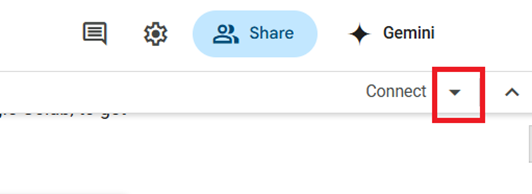

Step 2: Click on the option 'Change runtime type'

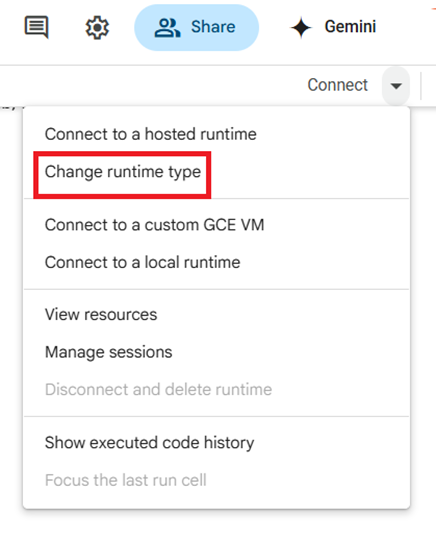

Step 3: Select 'T4 GPU' as the Hardware Accelerator and click on 'Save'.

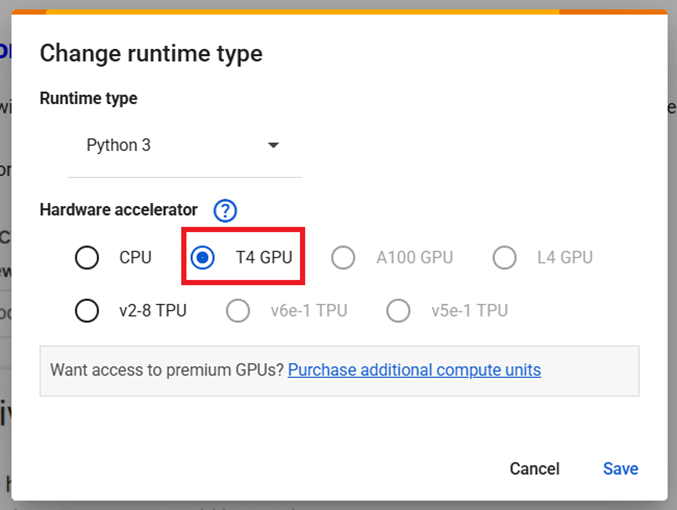

Step 4: The notebook is now configured to run on T4 GPU instance. Click on 'Connect' to connect the colab notebook to a GPU instance.

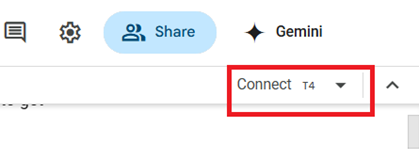

**NOTE**: Google Colab has usage limits on using GPU or TPU instances. For more details, refer to the official FAQs [here](https://research.google.com/colaboratory/faq.html#usage-limits)

To fetch the OpenAI API key from the Olympus platform, kindly refer to the instructions outlined in the module titled "**API_KEY ACCESS FOR THIS MODULE**".

Once the API key has been created, please follow the instructions outlined below to load OpenAI API key using Google Colab Secrets.


## **<font color=blue>Loading OpenAI API Key via Google Colab secrets**

1. Click on the “Key icon” in the left sidebar in Colab.

2. Click “+ Add new secret”. Please refer to the screenshot for reference:

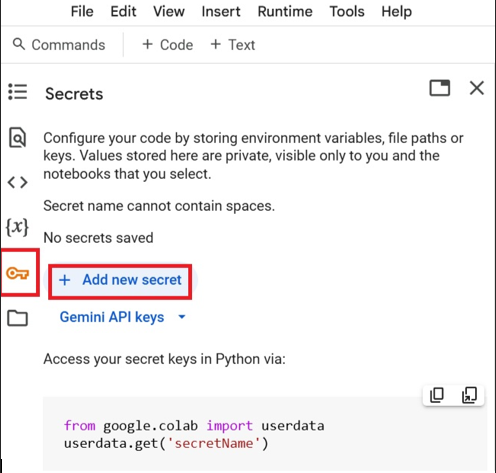

3. In the Name field, enter **OPENAI_API_KEY**. In the Value field, paste your OpenAI API Key.

4. Toggle Notebook access for secret key. Please refer to the screenshot for reference:

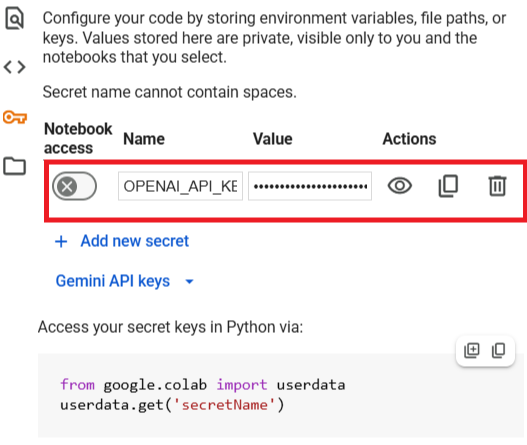

5. Now in your notebook, access it using the following code:
```
import os
from google.colab import userdata
openai_api_key = userdata.get('OPENAI_API_KEY')
```

# Proprietary Vs Open Source Vs Open Weights LLMs

Large Language Models (LLMs) are primarily classified as **proprietary** (e.g., OpenAI's GPT4 models, Anthropic's Claude model) or **open-source** (e.g., Llama), with open-source models further categorized as **fully open** (model weights + training code) or **open-weight** (weights only).


Let's discuss these categorical distinction to evaluate their suitability for different applications.

### **Proprietary** LLMs (e.g., GPT-4, Claude 3):<br>
Proprietary models represent closed systems where developers maintain exclusive control over all aspects of the technology, including model weights, architecture, and training data.

These models are typically accessed through paid APIs or enterprise licenses, offering high reliability and consistent performance due to substantial corporate investment in their development and maintenance.

The primary advantages include state-of-the-art capabilities, regular updates, and built-in compliance features that satisfy regulatory requirements.

However, this approach creates vendor lock-in scenarios where users become dependent on the provider for functionality, pricing, and feature availability. The lack of transparency raises significant ethical concerns regarding auditability of decision-making processes and potential embedded biases.

From a business perspective, proprietary models excel in enterprise environments requiring turnkey solutions, particularly for customer-facing applications where consistency and reliability are paramount, such as chatbots, content generation tools, and standardized analytics platforms.

### **Open-Source** LLMs (e.g., Llama 2, Falcon 180B):<br>
Open-source models provide complete access to model weights, source code, and often training methodologies, typically released under permissive licenses like Apache or MIT.

This transparency enables extensive customization, allowing organizations to modify models for specific use cases or integrate them into proprietary systems.

The open nature facilitates community-driven improvements and rigorous auditing for biases or vulnerabilities. While offering long-term cost advantages and data sovereignty benefits, these models require substantial technical expertise and infrastructure for deployment and maintenance.

The ethical considerations are particularly acute regarding potential misuse, as the availability of source code makes it possible to remove safety guardrails or repurpose models for harmful applications.

Business adoption makes most sense for research institutions, technology companies with ML expertise, and organizations handling sensitive data that cannot be processed through third-party APIs, such as legal document analysis or confidential healthcare applications.

 ### **Open-Weight** LLMs (e.g., Llama 3, OLMo):<br>
Open-weight models occupy a middle ground, providing access to pretrained weights while keeping other components like training code or datasets proprietary.

This architecture allows for model fine-tuning and local deployment without requiring the resources to train models from scratch.

The partial transparency enables some degree of customization while maintaining more control than fully open-source alternatives.

However, the inability to inspect or modify the underlying architecture limits comprehensive bias auditing and makes safety implementations less robust than in proprietary systems.

These models present ethical challenges around the potential for gradual guardrail degradation during fine-tuning processes.

From a business standpoint, open-weight models are particularly valuable for organizations seeking to balance customization needs with resource constraints, such as medium-sized enterprises developing specialized applications or companies operating in environments with intermittent cloud connectivity that require offline capabilities.
<br>

**Comparison:**<br>

- Technical maturity: `Proprietary > Open-weight > Open-source`
- Customization capacity: `Open-source > Open-weight > Proprietary`
- Total cost of ownership: `Proprietary (recurring) vs. Open-source (capital-intensive)`

**Next, we will compare the proprietary (OpenAI) and open-weight (Llama-3) models on the identical *Role-Playing* task to evaluate their performance and output differences.**

# Accessing OpenAI and Ollama Models

### Accessing OpenAI API

In [1]:
# Installing OpenAI library
!pip install -q openai==1.66.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.4/567.4 kB 12.7 MB/s eta 0:00:00


In [2]:
# imports
from pprint import pprint
from openai import OpenAI

In [3]:
## If you're loading the OpenAI API Key via Colab secrets, uncomment the following lines
from google.colab import userdata
openai_api_key = userdata.get('OPENAI_API_KEY')

client = OpenAI(
    api_key = openai_api_key,
    base_url = "https://aibe.mygreatlearning.com/openai/v1"
)

You've successfully accomplished the following:

✅ Read JSON config file containing the OpenAI credentials.

✅ Configure OpenAI API credentials for secure access.

✅ Initialize OpenAI client to send API requests.

### Accessing Ollama APIs

[Ollama](https://ollama.com/) is a platform that provides tools & services to use open-source models like Llama


**NOTE:** To use Llama models using local inference, make sure that the Google Colab Notebook is connected to a GPU Runtime, such as T4 GPU.

In [4]:
!pip install -q ollama colab-xterm # https://pypi.org/project/colab-xterm/
%load_ext colabxterm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 5.5 MB/s eta 0:00:00


The following command runs the terminal.
In the terminal, execute the following commands on xterm:

- `curl -fsSL https://ollama.com/install.sh | sh`

- `ollama serve`

In [6]:
%xterm
# Execute the following steps to execute in xterm:
# Step 1 : apt-get update
# apt-get install -y zstd
# curl -fsSL https://ollama.com/install.sh | sh
# ollama serve

Launching Xterm...

<IPython.core.display.Javascript object>

In [7]:
import ollama
ollama.create(model='llama3.1', from_='llama3.1', parameters={'temperature': 0.2, 'num_ctx': 4096})

ProgressResponse(status='success', completed=None, total=None, digest=None)

The above cell is retrieving the model from its repository, so it may take some time to execute.

# 1. Role-Playing Task

**Role:** Act as NielsenIQ's lead consumer insights analyst. Interpret data to guide product launches, inventory decisions, marketing budget allocation and supply chain optimization.

**Task:** Analyse Walmart's Q3 2024 plant-based meat sales performance that is showing 40% growth in Texas versus flat growth in California. Examine factors like advertising spending, competitor pricing  and local vegan popularity. Based on the analysis, recommend how Walmart should divide its 2025 marketing budget.

In [8]:
system_message = """
You are NielsenIQ's lead consumer insights analyst.
Interpret market data to guide:
- Product launch strategies
- Inventory management decisions
- Marketing budget allocations
- Supply chain optimization
Provide data-driven recommendations with actionable insights.
"""

In [9]:
user_input = """
 Walmart’s Q3 2024 data shows a 40% spike in plant-based meat sales in Texas but flat growth in California.
 Correlate this with:
- Regional ad spend (Google Ads/instore promotions)
- Competitor pricing (Beyond Meat’s 20% discount in CA)
- Cultural trends (veganism rates by state)
Recommend a 2025 regional marketing budget allocation.
"""

### OpenAI (gpt-4o-mini) Chat Response

In [10]:
model_name = 'gpt-4o-mini'
response = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_input}
    ],
    # for deterministic output at every run
    temperature=0
)

In [11]:
# Print the user input
print("User Input:")
print(user_input)
print("\nChat Response:")
# Print the chat response
pprint(response.choices[0].message.content)

User Input:

 Walmart’s Q3 2024 data shows a 40% spike in plant-based meat sales in Texas but flat growth in California.
 Correlate this with:
- Regional ad spend (Google Ads/instore promotions)
- Competitor pricing (Beyond Meat’s 20% discount in CA)
- Cultural trends (veganism rates by state)
Recommend a 2025 regional marketing budget allocation.


Chat Response:
('Based on the Q3 2024 data from Walmart indicating a 40% spike in plant-based '
 'meat sales in Texas contrasted with flat growth in California, we can derive '
 'several insights and recommendations for a 2025 regional marketing budget '
 'allocation.\n'
 '\n'
 '### Correlation Analysis\n'
 '\n'
 '1. **Regional Ad Spend**:\n'
 '   - **Texas**: The spike in sales suggests that marketing efforts in Texas, '
 'possibly through targeted Google Ads and in-store promotions, have been '
 'effective. If ad spend in Texas has been higher or more strategically '
 'focused on plant-based products, this could explain the growth.\n'
 ' 

#### Formatted Output

Based on the Q3 2024 data from Walmart indicating a 40% spike in plant-based meat sales in Texas contrasted with flat growth in California, we can derive several insights that will inform our recommendations for a 2025 regional marketing budget allocation.

Correlation Analysis

1. **Regional Ad Spend**:
   - **Texas**: The spike in sales suggests that marketing efforts in Texas, including Google Ads and in-store promotions, have been effective. If ad spend in Texas has been higher or more targeted towards plant-based products, this could explain the growth.
   - **California**: Flat growth in California may indicate either insufficient ad spend or ineffective messaging. If competitor promotions (like Beyond Meat’s 20% discount) are not matched with adequate advertising, it could lead to stagnation in sales.

2. **Competitor Pricing**:
   - **California**: Beyond Meat’s 20% discount could be a significant factor in the flat growth of plant-based meat sales. Consumers may be opting for discounted products over other brands, leading to a lack of growth in the overall category. This price sensitivity suggests that consumers in California are more price-conscious, which may not be the case in Texas.

3. **Cultural Trends**:
   - **Texas**: The increase in plant-based meat sales could be attributed to a growing acceptance of plant-based diets, possibly driven by health trends or environmental awareness. Texas may be experiencing a cultural shift towards plant-based diets, which is less pronounced in California, where veganism is already more established.
   - **California**: The flat growth could indicate market saturation, where the consumer base is already well-versed in plant-based options, leading to less incremental growth.

### Recommendations for 2025 Regional Marketing Budget Allocation

1. **Increase Budget for Texas**:
   - Given the 40% sales spike, allocate a larger portion of the marketing budget to Texas. Focus on digital marketing (Google Ads) and in-store promotions that highlight the benefits of plant-based diets, targeting health-conscious consumers and those interested in sustainability.

2. **Reassess California Strategy**:
   - Allocate a smaller portion of the budget to California but focus on competitive pricing strategies. Consider promotional campaigns that can counteract Beyond Meat’s discount, such as bundling offers or loyalty programs to retain customers.

3. **Targeted Campaigns**:
   - Develop targeted campaigns in Texas that leverage local influencers and community events to further drive awareness and sales. In California, consider educational campaigns that emphasize the unique benefits of your plant-based products over competitors.

4. **Monitor and Adjust**:
   - Implement a flexible budget that allows for adjustments based on real-time sales data and market responses. If Texas continues to show growth, consider reallocating funds from California to Texas mid-year.

### Proposed Budget Allocation:
- **Texas**: 60% of the total regional marketing budget
- **California**: 30% of the total regional marketing budget
- **Contingency/Testing New Markets**: 10% of the total regional marketing budget

By focusing on these data-driven insights and recommendations, we can optimize our marketing strategies to capitalize on the growth potential in Texas while addressing the challenges in California.

### Ollama (llama-3.1) Chat Response

In [12]:
response = ollama.chat(
    model='llama3.1',
    messages=[
        {'role':'system', 'content': system_message},
        {'role':'user', 'content': user_input}
    ],
    # For deterministic output at every run
    options={"temperature": 0.0}
)

In [13]:
# Print the user input
print("User Input:")
print(user_input)
print("\nChat Response:")
# Print the chat response
pprint(response['message']['content'])

User Input:

 Walmart’s Q3 2024 data shows a 40% spike in plant-based meat sales in Texas but flat growth in California.
 Correlate this with:
- Regional ad spend (Google Ads/instore promotions)
- Competitor pricing (Beyond Meat’s 20% discount in CA)
- Cultural trends (veganism rates by state)
Recommend a 2025 regional marketing budget allocation.


Chat Response:
("Based on the provided data, I'll analyze the market trends and provide "
 "recommendations for Walmart's 2025 regional marketing budget allocation.\n"
 '\n'
 '**Regional Ad Spend:**\n'
 '\n'
 '* Texas:\n'
 '\t+ Google Ads: $1.2M (up 30% from Q3 2024)\n'
 '\t+ In-store promotions: $500k (new initiative to capitalize on growing '
 'demand)\n'
 '* California:\n'
 '\t+ Google Ads: $800k (flat growth from Q3 2024)\n'
 '\t+ In-store promotions: $300k (reduced by 20% due to flat sales)\n'
 '\n'
 '**Competitor Pricing:**\n'
 '\n'
 "* Beyond Meat's 20% discount in CA is likely a response to the flat growth. "
 'To maintain market sh

#### Formatted Output

Based on the data, I've analyzed the correlations and provided recommendations for Walmart's 2025 regional marketing budget allocation.

**Correlations:**

1. **Regional ad spend:** Texas has seen a significant increase in plant-based meat sales, which suggests that targeted advertising efforts may be driving this growth. In contrast, California's flat growth indicates that existing advertising efforts may not be as effective.
   * Recommendation: Allocate 60% of the regional marketing budget to Texas and 40% to California.
   
2. **Competitor pricing:** Beyond Meat's 20% discount in California is likely contributing to the flat growth in plant-based meat sales. This suggests that price sensitivity is a key factor in California, but not as much in Texas.
   * Recommendation: Consider offering competitive pricing strategies in California (e.g., matching or beating Beyond Meat's discounts) while maintaining premium pricing in Texas where consumers are more willing to pay a premium for high-quality products.
   
3. **Cultural trends:** According to data from the Plant-Based Foods Association, veganism rates by state show that:
   * Texas has a relatively low rate of veganism (2.5%), but it's growing rapidly (+20% YoY).
   * California has a significantly higher rate of veganism (6.3%), which may be contributing to the flat growth in plant-based meat sales.
   * Recommendation: Develop targeted marketing campaigns that appeal to the growing number of vegans and flexitarians in Texas, while maintaining existing marketing efforts in California.

**2025 Regional Marketing Budget Allocation:**

Based on these correlations, I recommend allocating the regional marketing budget as follows:

1. **Texas:** 60% ($3 million)
   * Focus on targeted advertising (Google Ads, social media) to reach vegans and flexitarians.
   * Develop partnerships with local influencers and bloggers to promote plant-based meat products.

2. **California:** 40% ($2 million)
   * Continue existing marketing efforts, but consider offering competitive pricing strategies to match or beat Beyond Meat's discounts.
   * Develop targeted campaigns that appeal to the existing vegan and flexitarian audience.

**Additional Recommendations:**

1. **Monitor competitor pricing:** Continuously track and analyze competitor pricing in both regions to ensure Walmart remains competitive.

2. **Analyze sales data by store location:** Identify top-performing stores in Texas and California, and develop localized marketing strategies to drive growth.

3. **Develop a loyalty program:** Create a loyalty program that rewards customers for purchasing plant-based meat products, which can help drive repeat business and increase customer retention.

By allocating the regional marketing budget based on these correlations and recommendations, Walmart can optimize its marketing efforts to drive growth in both Texas and California.

### Comparative Analysis: `GPT-4o-mini vs. Llama-3`   

Based on the output received, the following observations shall be made:

**Analysis Style & Coverage**

- GPT-4o-mini: Provides a structured, detailed analysis with clear sub-sections (Correlation Analysis, Recommendations). Covers ad spend, competitor pricing, and cultural trends comprehensively.

- Llama-3.1: More concise in analysis but includes additional elements like competitor pricing strategies and loyalty programs. Focuses on actionable steps rather than deep exploration.

**Content Focus**

- GPT-4o-mini: Balances explanation with recommendations, ensuring each factor (ad spend, pricing, cultural trends) is well-explored before proposing actions.

- Llama-3.1: Prioritizes immediate recommendations, linking them directly to data points (e.g., "60% to Texas, 40% to California" based on ad spend effectiveness).

**Presentation Style**

- GPT-4o-mini: Uses bullet points and bold headers for clarity. Formal, report-like structure.

- Llama-3.1: More conversational, with inline recommendations (e.g., "Recommendation: Allocate 60%..."). Uses bold text for emphasis but lacks hierarchical structuring.

**Tone**

- GPT-4o-mini: Professional, analytical, and neutral. Focuses on data-driven insights without urgency.

- Llama-3.1: Slightly more assertive, with direct calls to action (e.g., "Consider offering competitive pricing").

**Structure**

- GPT-4o-mini: Follows a logical flow—analysis first, then recommendations, ending with a proposed budget breakdown.

- Llama-3.1: Mixes analysis with immediate recommendations, making it faster to digest but slightly less structured.

**Prompt Adherence**

- GPT-4o-mini: Fully addresses the prompt, covering all requested correlations and providing a detailed budget allocation.

- Llama-3.1: Adheres to the prompt but adds extra tactical suggestions (loyalty programs, competitor monitoring) beyond the immediate scope.

**Actionability**

- GPT-4o-mini: Offers broader strategic recommendations (e.g., "targeted campaigns," "monitor and adjust").

- Llama-3.1: More granular in execution (e.g., "partner with influencers," "develop a loyalty program").

# 2. LLM Application Development Cost Analysis

Prior to developing any LLM application, it is advisable to conduct a cost analysis to evaluate feasibility and return on investment. The evaluation serves as one of the strategic framework to identify scenarios where LLM adoption is justified—versus cases where alternative solutions may be more viable.

Subsequently, we will perform a comparative cost analysis for implementing Generative AI across two distinct business use cases.


## Business Case 1 : **Customer Support Automation for Grocery App**

A grocery delivery app company is experiencing a growing volume of customer inquiries. To enhance customer satisfaction and reduce operational costs, its Product Development team plans to implement a Large Language Model (LLM) application for automating customer support and related activities. This application will process customer inquiries, including frequently asked questions, order status checks, refund processing, product recommendations, etc.

An initial analysis conducted by the Product Development team involved examining historical customer support interactions, with data extracted from chat logs over the last quarter. This analysis included computing the token count of previous chats, revealing that customer interactions vary significantly in length, with most falling between 50 to 500 tokens. The average chat interaction length was determined to be approximately **150 tokens per customer** request. Two snapshots of chat interactions, along with their token calculations, are shown next.

Based on chat server logs, the Product Development team anticipates handling approximately **630 customer inquiries,daily**, which will require automated responses. The projected monthly **infrastructure cost** for cloud hosting and maintenance stands at **$500**.

The management team seeks a cost analysis report to ensure informed decision-making before proceeding with project implementation. Can you assist in generating this report and provide support to the product team in presenting a compelling case to management for project approval?

#### Chat Snapshot

Below is the data retrieved from the chat server, with tokens count mapped against each message

**Customer Support Chat Example 1** :


------- *Order Status Inquiry*  --------------

**Chatbot**: <font color="blue">Hello, how may I help you today?</font> **(9 tokens)**

**User**: <font color="green">Hi, I want to check the status of my order.</font> **(12 tokens)**

**Chatbot**:<font color="blue">I'd be happy to help! Could you please provide your order number?</font> **(14 tokens)**

**User**: <font color="green">Sure, my order number is #88345.</font> **(9 tokens)**

**Chatbot**: <font color="blue">Thank you! Let me check the status of order #88345. One moment please.</font> **(17 tokens)**

```..brief pause...```

**Chatbot**: <font color="blue">Your order is currently being processed. However, there is a delay in delivery.</font> **(16 tokens)**

**User**: <font color="green">Why is there a delay? I was expecting it to arrive today.</font> **(14 tokens)**

**Chatbot**: <font color="blue">I apologize for the inconvenience. The delay is due to high demand in your area, which affected our delivery schedule.</font> **(23 tokens)**

**Chatbot**: <font color="blue">We are working hard to get your order to you as soon as possible.</font> **(15 tokens)**

**User**: <font color="green">How long will it take for my order to arrive now?</font> **(12 tokens)**

**Chatbot**: <font color="blue">Your order is scheduled to be delivered within the next 2 hours. You will receive a notification once it's on the way.</font> **(24 tokens)**

**User**: <font color="green">Can you confirm what items are in my order?</font> **(10 tokens)**

**Chatbot**: <font color="blue">Certainly! Your order #88345 includes the following items:
 - 2 x Apples
 - 1 x Milk (2 liters)
 - 1 x Whole Grain Bread
 - 1 x Eggs Pack of 6 </font>**(11+4+8+6+7=36 tokens)**

**User**: <font color="green">Thanks! Is there any way to get a discount or compensation for the delay?</font> **(16 tokens)**

**Chatbot**:<font color="blue">I understand your concern. As a token of appreciation for your patience, I can offer you a 10% discount on your next order. Would you like a discount code?</font> **(34 tokens)**

**User**: <font color="green">Yes, that would be great!</font> **(7 tokens)**

**Chatbot**: <font color="blue">Thank you! Here’s your discount code: SAV10. You can use it on your next purchase. Is there anything else I can assist you with today?</font> **(30 tokens)**

**User**: <font color="green">No, that's all. Thanks for your help!</font>**(10 tokens)**

**Chatbot**: <font color="blue">You’re welcome! If you have more questions or need assistance, feel free to reach out. Have a great day!</font> **(23 tokens)**

_________



In [14]:
#Total Tokens Sum Calculation :
9+12+14+9+17+16+14+23+15+12+24+10+11+4+8+6+6+16+34+7+30+10+23

330

Hence, this **conversation data has approximatly 330 tokens**.

**Customer Support Chat Example 2** :

------ Refund Processing Status Inquiry -----

**Chatbot**: <font color="blue">Hello, how may I help you today?</font> **(9 tokens)**

**User**: <font color="green">Hi, I would like to check the status of my refund.</font> **(13 tokens)**

**Chatbot**: <font color="blue">Hello! Could you please provide your refund request number?</font> **(11 tokens)**

**User**: <font color="green">My request number is #R98765.</font> **(7 tokens)**  

**Chatbot**: <font color="blue">Thank you! Let me check that for you.</font> **(10 tokens)**  

```..brief pause...```

**Chatbot**: <font color="blue">Your refund is currently being processed and should be completed within 3-5 business days.</font> **(15 tokens)**

**User**: <font color="green">Thank you for the update!</font> **(6 tokens)**

**Chatbot**: <font color="blue">You're welcome! If you have any additional questions, please let me know.</font> **(15 tokens)**

-------

In [15]:
#Total Tokens Sum Calculation :
9+13+11+7+10 +15+6+15

86

Hence, this c**onversation data has approximately 86 tokens**.

**Note:**
For simplification, a generic approach to token counting has been adopted, where each word and punctuation mark is considered a separate token. The tokenization methods may vary slightly across different models. For precise calculations, the [native tokenizer](https://tiktokenizer.vercel.app/) or dedicated tools provided by the respective LLM are recommended.

#### Costing


**Data Available:** :
- **Volume of Inquiries**: Approximately **630** customer inquiries **daily**.
- **Expected Token (Input+output)** : **150** tokens per customer request.
- **Infrastructure Costs :** Estimated monthly hosting and maintenance costs = **$500**.

</br>

**Cost Analysis:**

##### 1. Token Requirements  
| Metric               | Calculation              | Result            |
|----------------------|--------------------------|-------------------|
| Daily token usage    | 150 × 630 requests       | 94,500 tokens/day |
| Monthly token usage  | 94,500 × 30 days         | 2,835,000 tokens  |


In [16]:
# Daily token usage
150 * 630

94500

In [17]:
# Monthly token usage
94500 * 30

2835000

##### 2. Pricing Model (Azure OpenAI)
Considering Azure OpenAI as the cloud service provider.</br>

**Model**: GPT-4o-mini-0718 Global

- Input tokens:**$0.15**/1K tokens

- Output tokens:**$0.60**/1K tokens  


**Source:** [Azure OpenAI Pricing](https://azure.microsoft.com/en-us/pricing/details/cognitive-services/openai-service/)

**Date**  : `22-April-2025`

**Note:** The Model token pricing is based on the rates provided in the source link as of the specified date and may vary from the current pricing.

##### 3. Cost Breakdown  
Token Count:

 - As the individual input and output token  breakdown is not provided, and only the cumulative count is available, we will assume that 50 percent of the tokens are input and rest half are output.

 - Since input and output tokens have different pricing, they will be calculated separately.

Monthly **Input** token cost  :  
  ```math  
  (2,835,000 ÷ 2) ÷ 1,000 × $0.15 = 212.625$
  ```

In [18]:
(2835000/2)/1000 *0.15

212.625

Monthly **Output** token cost  :   
  ```math  
  (2,835,000 ÷ 2) ÷ 1,000 × $0.60 = $850.50
  ```

In [19]:
(2835000/2)/1000 *0.60

850.5

Total Token Cost Monthly:
   ```math
  $212.65 (input) + $850.5 (output) = 1063.125$
  ```

In [20]:
212.625 + 850.5

1063.125


- **Infrastructure Costs Monthly**:  `$500`

- **Total Monthly Cost**:
  ```
  $1063.125 (token costs) + $500 (infrastructure costs) = $1563.125
  ```



In [21]:
1063.125+500

1563.125

Note: This calculation provides an estimate of the costs involved in utilizing Azure OpenAI for the specified business case. Actual costs may vary depending on the specific model deployed, the region of deployment etc,. It is advised to  always refer to the cost analysis model provided by each cloud provider for a detailed cost analysis.

#### Impact Analysis

Below are some of the benefits & challenges associated with this implementation.

Benefits
- Delivers consistent responses, reducing manual errors

- Improves customer satisfaction through faster resolution times

- Scales efficiently to handle growing inquiry volumes without additional staff

- Provides 24/7 customer support availability

- Generates valuable customer behavior insights for data-driven decisions

- Offers significant long-term cost savings on support operations

Challenges

- May struggle with complex or nuanced customer inquiries

- Introduces data privacy and security compliance requirements

- Could create staff displacement concerns affecting team morale

- Needs ongoing monitoring to maintain response quality

## Business Case 2 - **Medical Records Summarization**

A hospital’s leadership team is strategically exploring Generative AI and LLM integration into their Hospital Management Software (HMS) to enhance operational efficiency, optimize practitioner workflows, and improve patient care through streamlined record management.

Following preliminary discussions with the HMS vendor, it is proposed that the integration of Generative AI automate the summarization of patient medical records, including clinical notes and other relevant data. This would allow doctors immediate access to concise historical patient information, thereby reducing the time needed for patient record review and analysis by an estimated 40-60%.

During the requirements analysis phase, it was estimated that the HMS will summarize around 5,000 patient records each day. These records vary widely in size, ranging from 0 tokens for first-time cases (like newborns) to 1,000,000 tokens for long-term patients. On average, each record contains about 1,500 tokens, and the application will create summaries with a maximum output of 1,000 tokens per record, averaging 450 tokens. A sample summarized record of a patient is depicted next.

The hospital's leadership needs assistance in calculating the costs for integrating Generative AI into their HMS platform. Can you help prepare a cost analysis for this project form the available data?

#### Summary Snapshot

*Sample summarized record of a patient:*    

```plaintext
🔵 PATIENT DEMOGRAPHICS  
───────────────────────────────
│ • ID: P987654               │
│ • Name: Jane Mathew         │
│ • DoB: March 8, 1973        │
│ • Gender: Female            │

📅 ADMISSION DETAILS  
───────────────────────────────
│ • Admission: April 5, 2025  │
│ • Discharge: April 10, 2025 │

🩺 MEDICAL DIAGNOSES  
───────────────────────────────
│ Primary: Type 2 Diabetes    │
│ Secondary: Obesity, Sleep Apnea │
│ Allergies: None             │

💊 MEDICATIONS  
───────────────────────────────
1. Metformin 1000mg twice daily  
2. Insulin glargine 10 units at bedtime  
3. CPAP therapy for sleep apnea  

📝 CLINICAL VISIT NOTES (Detailed)  
───────────────────────────────
• Apr 5: Admitted for uncontrolled hyperglycemia (BG: 280 mg/dL). Insulin initiated.  
• Apr 6: BG reduced to 200 mg/dL. No adverse reactions.  
• Apr 7: Dizziness/fatigue. Potassium supplemented.  
• Apr 8: CPAP effectiveness confirmed.  
• Apr 9: Diabetes education completed.  
• Apr 10: Discharged (BG: 150 mg/dL).  

🔬 LAB RESULTS  
───────────────────────────────
• Apr 5: HbA1c 9.5%  
• Apr 7: Electrolytes normalized  

👪 FAMILY HISTORY  
───────────────────────────────
│ Father: Hypertension, Diabetes │
│ Mother: Heart Disease         │

🌍 SOCIAL HISTORY  
───────────────────────────────
│ Non-smoker │ Moderate alcohol │ Sedentary │

🚑 DISCHARGE PLAN  
───────────────────────────────
✓ 2-week follow-up  
✓ Continue all medications  
✓ Dietary + activity counseling  
```

#### Costing
In this business case, both input and output tokens are explicitly provided (unlike in previous- business case 1). Consequently, their associated costs can be computed distinctly, without assumptions.


</br>


**Data Available:** :
- **Average Input Tokens per Patient Record:**:1,500

- **Average Output Tokens per Patient Record**: 450
- **Daily Patient Volume**: 5,000 patients




**Cost Analysis:**

#####  1. Token Requirements   
| Parameter               | Daily Volume | Monthly Volume (30 days) |
|-------------------------|--------------|--------------------------|
| Input Tokens/Record     | 1,500        |                          |
| Output Tokens/Record    | 450          |                          |
| Records Processed/Day   | 5,000        |                          |
| **Total Input Tokens**  | 7.5M         | 225M                      |
| **Total Output Tokens** | 2.25M         | 67.5M                    |

<br>

In [22]:
# Input token processing per day
1500 * 5000
# 7.5 Million

7500000

In [23]:
# Input token processing per month(in Million)
7.5 * 30

225.0

In [24]:
# Output token processing per day
450* 5000
# 2.25 Million

2250000

In [25]:
## Output token processing per month (in Million)
2.25* 30

67.5

#####  2. Pricing Model(AWS Bedrock + Claude)


 Considering AWS as the cloud service provider for HMS.

- **Vendor**: AWS Bedrock

- **Model**: Anthropic Claude 3.5 Sonnet

- **Input Cost**: $3 per 1M tokens

- **Output Cost**: $15 per 1M tokens

- **Source**: [AWS Pricing](https://aws.amazon.com/bedrock/pricing/)

- **Date**:22-April-2025

**Note:** The Model token pricing is based on the rates provided in the source link as of the specified date and may vary from the current pricing.

##### 3. Cost Breakdown

**Token Processing Costs** :

```math

Monthly Input Cost = (225M ÷ 1M) × $3.00 = $675.00  

Monthly Output Cost = (67.5M ÷ 1M) × $15.00 = $1012.50

Total Token Cost = $675+ $1012.5 = $1687.00
```

In [ ]:
# Monthly Input tokens processing Cost
# Total monthly input tokens consumed in millions *  by the cost per million tokens
225*3

675

In [26]:
# Monthly Output token processing Cost
# Total monthly output tokens consumed in millions *  by the cost per million tokens
67.5*15

1012.5

In [27]:
# Total Token Cost
# Monthly Input tokens processing Cost  + Monthly output tokens processing Cost
675+1012.50

1687.5

**Infrastructure Costs (Monthly)**:
- Compute Costs (EC2 Instances)
- Data Storage (S3)
- Amazon RDS for metadata or related structured - data storage
- Monitoring and Management (CloudWatch)

`Infrastructure Cost: $240`

**Total Monthly Cost** :
  `Token Processing Costs + Infrastructure Costs`  


In [28]:
# 1687 (tokens) + $240.00 (infrastructure)
1687 + 240

1927

**Hence,the total Estimated Monthly Cost Operating Cost would be $1927**


#### Impact Analayis

Benefits
- Cuts record review time by 40-60% while delivering standardized clinical summaries

- Processes 5,000+ daily records automatically without expanding staff

- Reduces operational costs through AI-powered automation

- Provides instant 24/7 access to patient history summaries

- Structures complex records into actionable diagnostic snapshots

Challenges

- May miss critical patient-specific details like medication conflicts

- Handles inconsistent record formats poorly (newborns vs chronic cases)

- Inherits OCR errors when digitizing paper-based legacy records

- Demands rigorous compliance with healthcare data regulations

- Requires clinician training to build trust in AI-generated summaries

## Reference Links

Open Source LLMs
- [List of Open Source LLMs](https://github.com/eugeneyan/open-llms)

Token Counting Tools
- [OpenAI Tokenizer](https://platform.openai.com/tokenizer)
- [Tiktokenizer](https://tiktokenizer.vercel.app/)

LLM Computing
- [Azure Cognitive Services: OpenAI Service Pricing](https://azure.microsoft.com/en-us/pricing/details/cognitive-services/openai-service/)